In [1]:
import seaborn as sns 
import pandas as pd 
from utils.score import get_summary  

sns.set_theme(
    style="whitegrid",
    context="paper",
    font="serif"
)
model_results = {} 
vqa_1k = get_summary('vqa_1k')  
vqa_5k = get_summary('vqa_5k')   
vqa_5k['condition'] = (
    vqa_5k['condition']
    .astype(str)
    .str.replace('vqa 5k ', '', regex=False)
    .str.replace('vqa 5k', '', regex=False)
    .str.strip()
)
vqa_5k.condition.unique() 

75
82


array(['', 'blind', 'inst blind', 'sys inst blind'], dtype=object)

In [2]:
import sys 
sys.path.append('..')
from score_humans import get_vqa_mapper, VQAAnswerMapper 

vqa_answers = get_vqa_mapper()  
vqamapper = VQAAnswerMapper()
vqamapper._load()
vqa_annot = vqamapper.annotations 

human_vqa = pd.read_json('/home/work/yuna/HPA/evaluation/scored/humans/human_vqa_per_question.json')
human_vqa['model'] = "humans" 
human_vqa['meta_model'] = "humans"
human_vqa['condition'] = "inst blind" 
human_vqa.rename(columns={"mean_accuracy": 'correct', 'qid': 'question_id'}, inplace=True) 
human_vqa['correct'] = pd.to_numeric(human_vqa['correct'], errors='coerce')
human_vqa['correct'] = (human_vqa['correct'] * 100).round(1) 
human_vqa['question_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['question_type'] if int(qid) in vqa_annot else None)
human_vqa['answer_type'] = human_vqa['question_id'].map(lambda qid: vqa_annot[int(qid)]['answer_type'] if int(qid) in vqa_annot else None)

qids = human_vqa.question_id.unique()

model_vqa = vqa_1k[vqa_1k['question_id'].isin(qids)]   
hm = pd.concat([model_vqa, human_vqa]) # pt.to_csv(f'./tables/vqa_human_comparison.csv')      

   Loading VQA annotations from /home/work/yuna/VLMEval/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations


In [19]:
human_df = hm[hm['model'] == 'humans'] 
human_df.groupby(['question_type', 'answer_type']).agg({'answer_similarity': 'mean', 'correct': 'mean'}).reset_index()
# human_df.groupby(['question_type', 'answer_type']).agg({'answer_similarity': 'count', 'correct': 'count'}).reset_index()

,question_type,answer_type,answer_similarity,correct
0,are,yes/no,0.832859,68.807857
1,are the,other,0.685389,35.897436
2,are the,yes/no,0.812950,59.726733
3,are there,yes/no,0.798402,46.000000
4,are there any,yes/no,0.844171,63.000000
...,...,...,...,...
63,where is the,other,0.418012,15.554167
64,which,other,0.315116,9.583750
65,who is,other,0.328481,12.999000
66,why,other,0.273447,0.999000


In [3]:
def aggregate_vqa(df): 
    df = df.groupby(['model', 'question_type', 'answer_type', 'condition']).agg({'correct': 'mean', 'answer_similarity': 'mean'}).reset_index()
    df = df.dropna(axis=0, subset=['answer_similarity'])

    pt = df.pivot_table( 
        index=['model', 'answer_type', 'question_type'], 
        columns=['condition'],   
        values=['correct', 'answer_similarity' ] ,
        aggfunc=['mean', ] # 'count'  
    ).round(1).reset_index() 

    return pt  
    
def calculate_mg(df, filename=None, answer_similarity=True, categories='answer_type'): 

    if categories == 'answer_type': 
        pt = aggregate_vqa(df) 

    pt['Acc_Visual'] = pt[('mean', 'correct', '')] 
    pt['Acc_Blind_inst'] = pt[('mean', 'correct', 'inst blind')] 
    pt['MG_Acc'] = pt[('mean', 'correct', '')] - pt[('mean', 'correct', 'inst blind')]
    
    if answer_similarity: 
        pt['S_Visual'] = pt[('mean', 'answer_similarity', '')]
        pt['S_Blind_inst'] = pt[('mean', 'answer_similarity', 'inst blind')]
        pt['MG_S'] = pt[('mean', 'answer_similarity', '')] - pt[('mean', 'answer_similarity', 'inst blind')]
        pt['Delta_Inst'] = pt[('mean', 'correct', 'blind')] - pt[('mean', 'correct', 'inst blind')]

    pt = pt[[col for col in pt.columns if not (isinstance(col, tuple) and col[0] == 'mean')]]
    pt.columns = [col[0] if isinstance(col, tuple) and len(col) > 1 else col for col in pt.columns] 
    
    if filename is not None : 
        ### INSTRUCTION GAINS  
        pt.pivot_table( 
            index=['model'], 
            values=['Acc_Visual', 'MG_Acc', 'Delta_Inst'], 
            aggfunc='mean'
            ).reindex(columns=['Acc_Visual', 'MG_Acc','Delta_Inst']).to_latex(f'./tables/VQA_{filename}_inst.tex', float_format="%.1f")
        
        ### BLIND ACC Ablabiotns by answer type 
        pt.pivot_table( 
            index=['model'], 
            columns=[categories],   
            values=['Acc_Blind_inst', 'MG_Acc'], 
            aggfunc='mean'
            ).to_latex(f'./tables/VQA_{filename}_prior_acc_mg_atype.tex', float_format="%.1f")
        
        ### GT ACC Ablabiotns by answer type 
        pt.pivot_table( 
            index=['model'], 
            columns=[categories],   
            values=['Acc_Visual', 'MG_Acc'], 
            aggfunc='mean'
            ).to_latex(f'./tables/VQA_{filename}_acc_atype.tex', float_format="%.1f")
        
        ### WITHOUG ANSWER TYPE  
        pt.pivot_table( 
            index=['model'],  
            values=['Acc_Visual', 'MG_Acc'], 
            aggfunc='mean'
            ).reindex(columns=['Acc_Visual', 'MG_Acc']).to_latex(f'./tables/VQA_{filename}_acc.tex', float_format="%.1f")
        
        if answer_similarity: 
            pt.pivot_table( 
                index=['model'], 
                columns=[categories],   
                values=['S_Blind_inst', 'MG_S'], 
                aggfunc='mean'
                ).to_latex(f'./tables/VQA_{filename}_prior_sim_mg_atype.tex', float_format="%.1f") 
        
            pt.pivot_table( 
                index=['model'], 
                columns=[categories],   
                values=['S_Visual', 'MG_S'], 
                aggfunc='mean'
                ).to_latex(f'./tables/VQA_{filename}_similarity_atype.tex', float_format="%.1f") 
            
            pt.pivot_table( 
                index=['model'], 
                values=['S_Visual', 'MG_S'], 
                aggfunc='mean'
                ).reindex(columns=['S_Visual', 'MG_S']).to_latex(f'./tables/VQA_{filename}_similarity.tex', float_format="%.1f") 
            
    return pt  

In [4]:
df = calculate_mg(vqa_5k, filename='vqa_5k') 
df = calculate_mg(vqa_1k, filename='vqa_1k') 
df = calculate_mg(hm, filename='human_model') 
df

,model,answer_type,question_type,Acc_Visual,Acc_Blind_inst,MG_Acc,S_Visual,S_Blind_inst,MG_S,Delta_Inst
0,InternVL3_5-1B,number,how many,73.3,33.3,40.0,89.2,74.5,14.7,-8.3
1,InternVL3_5-1B,number,how many people are,100.0,0.0,100.0,100.0,61.0,39.0,0.0
2,InternVL3_5-1B,number,how many people are in,66.6,50.0,16.6,93.0,75.8,17.2,-50.0
3,InternVL3_5-1B,number,none of the above,100.0,0.0,100.0,100.0,36.7,63.3,0.0
4,InternVL3_5-1B,number,what,100.0,100.0,0.0,100.0,100.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
811,llava-v1.6-vicuna-7b-hf,yes/no,is this,96.8,71.4,25.4,96.2,88.6,7.6,0.0
812,llava-v1.6-vicuna-7b-hf,yes/no,is this a,87.5,72.9,14.6,88.4,85.0,3.4,2.1
813,llava-v1.6-vicuna-7b-hf,yes/no,is this an,100.0,0.0,100.0,100.0,73.4,26.6,0.0
814,llava-v1.6-vicuna-7b-hf,yes/no,none of the above,76.2,71.4,4.8,92.4,92.4,0.0,0.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr

def plot_scatter(grouped, model, score_col):
    fname = f"./figures/{model.split('/')[-1]}_{score_col}.png"

    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=grouped,
        x=f'{score_col}_human',
        y=f'{score_col}_model',
        s=50
    )
    sns.regplot(
        data=grouped,
        x=f'{score_col}_human',
        y=f'{score_col}_model',
        scatter=False,
        color='black'
    )

    plt.title(f'{model} ({score_col})')
    plt.xlabel('Human')
    plt.ylabel('Model')

    
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close() 

def get_correlation_by_model( 
    mmg,
    model, 
    score_col='answer_similarity',
    grouping=['question_type'], 
):

    model_type = mmg.meta_model.unique()[0] 
    df_model = mmg[mmg['model'] == model] 

    counts = df_model.groupby(grouping).size()  
    count_stats = {
        "num_question_types": int(len(counts)),
        "min_q_per_type": int(counts.min()),
        "median_q_per_type": float(counts.median()),
        "max_q_per_type": int(counts.max()),
    }

    grouped = (
        df_model
        .groupby(grouping)
        .agg({
            f'{score_col}_human': 'mean',
            f'{score_col}_model': 'mean'
        })
        .reset_index()
    )
    x = grouped[f'{score_col}_human']
    y = grouped[f'{score_col}_model']
    
    plot_scatter(grouped, model, score_col) 
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    spearman_r, spearman_p = spearmanr(x, y)
    score_human = float(x.mean())
    score_model = float(y.mean())

    return {
        "model": model.split('/')[-1],
        "model_type": model_type,
        "eval_metric": score_col,
        "pearson_r": r_value,
        "pearson_p": p_value,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "slope": slope,
        "intercept": intercept,
        "std_err": std_err,
        "model_avg": score_model,
        "human_avg": score_human,
        **count_stats,
    }, df_model

In [79]:
# def model_human_df(model, hm):  
df = hm[['meta_model', 'question_id', 'answer_type', 'question_type', 'model', 'question', 'answer', 'output', 'correct', 'answer_similarity']]
human_df = df[df['model'] == 'humans'] 
model_df = df[df['model'] != 'humans']  # == df.model.unique()[0]] 
mg = pd.merge( model_df, human_df.groupby(['question_id', 'answer_type', 'question_type']).mean(numeric_only=True).reset_index(), on=['question_id', 'answer_type', 'question_type'], how='left', suffixes=('_model', '_human') ) # .dropna(axis=1)

In [ ]:
results = []
for model in mg.model.unique(): 
    results.append(get_correlation_by_model(mg, model)[0]) 
    results.append(get_correlation_by_model(mg, model, score_col='correct')[0]) 

In [ ]:
grouped = pd.DataFrame(results)
grouped.to_csv('./tables/vqa_model_human_correlation.csv')  

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Pearson $r$ = 0.240 ($R^2$ = 0.058) | Spearman $\rho$ = 0.479


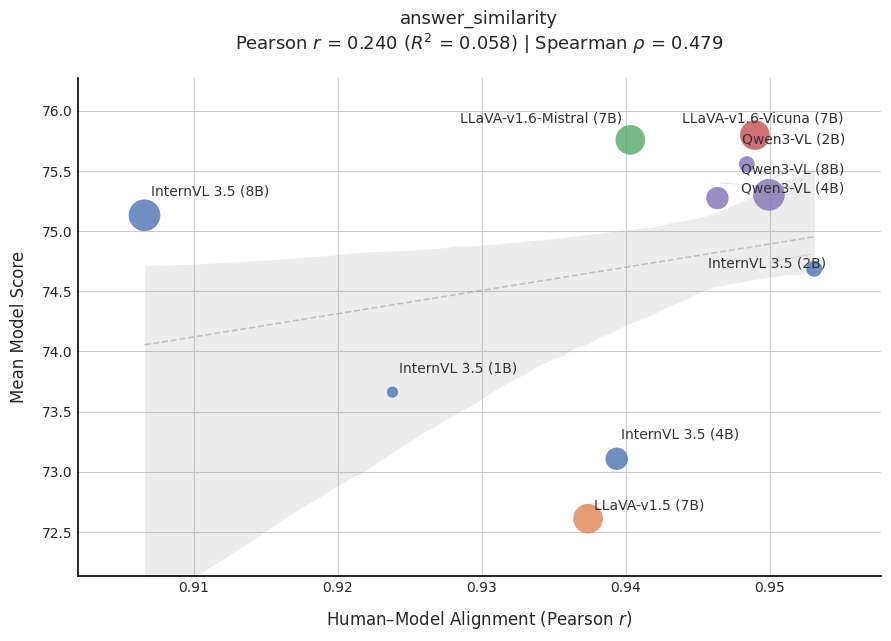

Pearson $r$ = -0.506 ($R^2$ = 0.256) | Spearman $\rho$ = -0.455


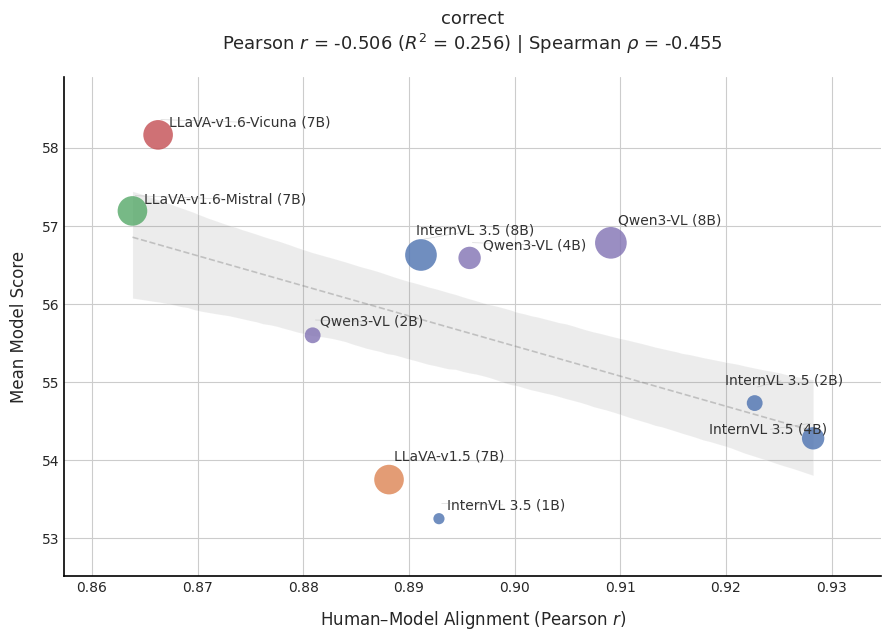

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, spearmanr
from adjustText import adjust_text


sns.set_style("whitegrid") # Very faint grid
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "axes.titlesize": 13,
    "axes.labelsize": 12, # Slightly larger for paper legibility
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.weight": "normal",
})
model_name_map = {
    'InternVL3_5-1B': 'InternVL 3.5 (1B)',
    'InternVL3_5-2B': 'InternVL 3.5 (2B)',
    'InternVL3_5-4B': 'InternVL 3.5 (4B)',
    'InternVL3_5-8B': 'InternVL 3.5 (8B)',
    'Qwen3-VL-2B-Instruct': 'Qwen3-VL (2B)',
    'Qwen3-VL-4B-Instruct': 'Qwen3-VL (4B)',
    'Qwen3-VL-8B-Instruct': 'Qwen3-VL (8B)',
    'llava-v1.6-mistral-7b-hf': 'LLaVA-v1.6-Mistral (7B)',
    'llava-1.5-7b-hf': 'LLaVA-v1.5 (7B)',
    'llava-v1.6-vicuna-7b-hf': 'LLaVA-v1.6-Vicuna (7B)'
}
grouped['model_clean'] = grouped['model'].map(model_name_map)  

for score_col in grouped["eval_metric"].unique():
    subset = grouped[grouped["eval_metric"] == score_col].sort_values(by=['model_clean'])

    x = subset["pearson_r"].values
    y = subset["model_avg"].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    spearman_r, _ = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(9, 6.5))

    # 1. Regression line + CI (68% for cleaner look)
    sns.regplot(
        data=subset, x="pearson_r", y="model_avg",
        scatter=False, ci=68, ax=ax,
        line_kws=dict(color="gray", linestyle="--", linewidth=1.2, alpha=0.4),
    )

    # 2. Scatter points
    for fam in subset["family"].unique():
        fam_data = subset[subset["family"] == fam]
        ax.scatter(
            fam_data["pearson_r"], fam_data["model_avg"],
            s=fam_data["model_size"] * 65,
            alpha=0.8, label=fam, edgecolors="none", zorder=3
        )

    # 3. Labeling
    texts = []
    for _, row in subset.iterrows():
        # offset the text a bit further away from the point
        text = ax.text(
            row["pearson_r"], row["model_avg"] + ((y.max() - y.min()) * 0.04),
            row["model_clean"],
            fontsize=10, color="#333333"
        )
        texts.append(text)

    adjust_text(
        texts,
        only_move={'points': 'y', 'text': 'xy'},
        arrowprops=dict(arrowstyle='-', color='gray', alpha=0.3, lw=0.5),
        expand_text=(1.5, 2.8),
        expand_points=(1.5, 2.8),
        force_text=0.15,
        force_points=0.15,
        lim=300,
    )

    # 4. DISTINCT AXIS FORMATTING
    # Show the left and bottom spines (the "L" frame)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.2)
    
    # Hide the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Make ticks visible and pointing outward
    ax.tick_params(left=True, bottom=True, direction='out', color='black', width=1.2)

    # Tighten limits based on data
    x_margin = (x.max() - x.min()) * 0.1
    y_margin = (y.max() - y.min()) * 0.15
    ax.set_xlim(x.min() - x_margin, x.max() + x_margin)
    ax.set_ylim(y.min() - y_margin, y.max() + y_margin)
    
    ax.set_xlabel("Human–Model Alignment (Pearson $r$)", labelpad=10)
    ax.set_ylabel("Mean Model Score", labelpad=10)
    
    ax.set_title(
        f"{score_col}\n"
        f"Pearson $r$ = {r_value:.3f} ($R^2$ = {r_value**2:.3f}) | Spearman $\\rho$ = {spearman_r:.3f}",
        pad=20,
    )

    print(f"Pearson $r$ = {r_value:.3f} ($R^2$ = {r_value**2:.3f}) | Spearman $\\rho$ = {spearman_r:.3f}") 
    plt.tight_layout()
    plt.savefig(f"./figures/alignment_{score_col}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
pm = mg[mg['model'].isin(pretrained_models)]
pm['answer_similarity_human'] = pm['answer_similarity_human']* 100 

In [191]:
pm

,meta_model,question_id,answer_type,question_type,model,question,answer,output,correct_model,answer_similarity_model,correct_human,answer_similarity_human
0,open-source model,356421011,other,what is the,InternVL3_5-1B,Question: What is the boy's skateboard balanci...,NaN,pole,0.0,24.3,0.00,24.202556
1,open-source model,11241003,yes/no,is this,InternVL3_5-1B,Question: Is this enough food for more than tw...,NaN,yes,100.0,100.0,75.00,83.196784
2,open-source model,537701022,yes/no,does this,InternVL3_5-1B,Question: Does this man's tie match the backgr...,NaN,no,100.0,100.0,64.99,81.094417
3,open-source model,135486006,other,what are,InternVL3_5-1B,Question: What are they carrying? Answer the q...,NaN,kite,100.0,100.0,0.00,21.693783
4,open-source model,305329002,other,what color is,InternVL3_5-1B,Question: What color is his helmet? Answer the...,NaN,black,100.0,100.0,40.00,68.123065
...,...,...,...,...,...,...,...,...,...,...,...,...
28045,open-source model,159842001,other,what color is,llava-v1.6-vicuna-7b-hf,Question: What color is her headband? Answer t...,NaN,Black,0.0,66.3,15.00,69.056939
28046,open-source model,430774001,number,what time,llava-v1.6-vicuna-7b-hf,Question: What time is shown on the clock? Ans...,NaN,0,0.0,28.9,0.00,44.988895
28047,open-source model,205352003,yes/no,are the,llava-v1.6-vicuna-7b-hf,Question: Are the people on the boat seen easi...,NaN,No,100.0,73.4,90.00,85.078915
28048,open-source model,580621000,other,what type of,llava-v1.6-vicuna-7b-hf,Question: What type of establishment are these...,NaN,Restaurant,100.0,100.0,0.00,33.221087


Accuracy
$r=0.46$, KS=0.50
Embedding
$r=0.58$, KS=0.47


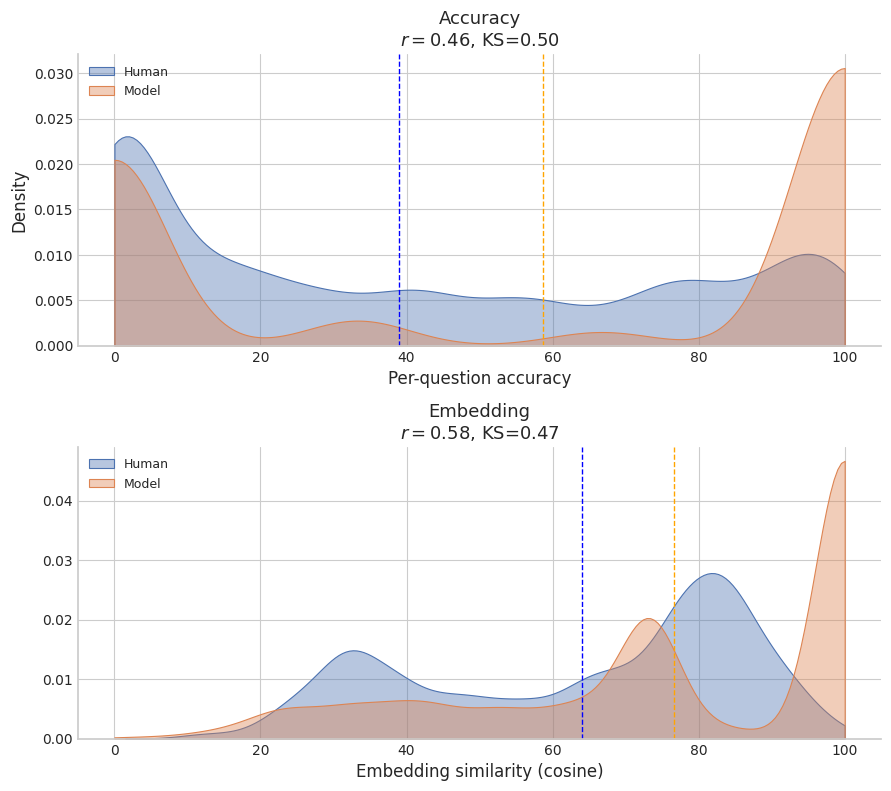

In [192]:
from scipy.stats import ks_2samp
import numpy as np

def aligned_histogram(x,y,x2,y2): 
    acc_corr = np.corrcoef(x, y)[0,1]
    acc_ks = ks_2samp(x, y)
    emb_corr = np.corrcoef(x2, y2)[0,1]
    emb_ks = ks_2samp(x2, y2)
    print(f"Accuracy\n$r={acc_corr:.2f}$, KS={acc_ks.statistic:.2f}")
    print(f"Embedding\n$r={emb_corr:.2f}$, KS={emb_ks.statistic:.2f}")

    fig, axes = plt.subplots(2,1, figsize=(9, 8))
    # --- Accuracy plot ---
    sns.kdeplot(x, fill=True, alpha=0.4, label="Human", ax=axes[0], clip=(0, 100))
    sns.kdeplot(y, fill=True, alpha=0.4, label="Model", ax=axes[0], clip=(0, 100))
    axes[0].axvline(x.mean(), color='blue', ls='--', lw=1)
    axes[0].axvline(y.mean(), color='orange', ls='--', lw=1)
    axes[0].set_xlabel("Per-question accuracy")
    axes[0].set_ylabel("Density")
    axes[0].set_title(f"Accuracy\n$r={acc_corr:.2f}$, KS={acc_ks.statistic:.2f}")
    axes[0].legend(frameon=False)

    # --- Embedding plot ---
    sns.kdeplot(x2, fill=True, alpha=0.4, label="Human", ax=axes[1], clip=(0, 100))
    sns.kdeplot(y2, fill=True, alpha=0.4, label="Model", ax=axes[1], clip=(0, 100)) 
    
    axes[1].axvline(x2.mean(), color='blue', ls='--', lw=1)
    axes[1].axvline(y2.mean(), color='orange', ls='--', lw=1) 
    axes[1].set_xlabel("Embedding similarity (cosine)")
    axes[1].set_ylabel("")
    axes[1].set_title(f"Embedding\n$r={emb_corr:.2f}$, KS={emb_ks.statistic:.2f}")
    axes[1].legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    # plt.savefig("./plots/distribution_comparison.pdf", bbox_inches='tight')
    plt.show()

aligned_histogram(pm['correct_human'], pm['correct_model'], pm['answer_similarity_human'], pm['answer_similarity_model']) 